# Two coupled $0$-$\pi$: $n_{\theta 1}\otimes n_{\theta 2}$

In [1]:
# import  os
# num_cores = "1"
# os.environ["OPENBLAS_NUM_THREADS"] = num_cores
# os.environ["OMP_NUM_THREADS"] = num_cores
# os.environ["MKL_NUM_THREADS"] = num_cores

In [2]:
import sys
sys.path.append('../')

import numpy as np
import scipy.sparse as ssp
import matplotlib.pyplot as plt
import qutip as qt
import scqubits as scq
from matplotlib.colors import LogNorm
from tqdm import tqdm
from qutip.qip.operations import rz, cz_gate
import cmath
from sympy import symbols
from scipy.sparse.linalg import eigsh
import utils_2Q_gate_zp as ut
from joblib import Parallel, delayed
from IPython.display import display, Math
# ut.set_fig_font() ### Set various sizes in plotting

### 3. Construct subsystem, calculate eigenvalues

In [3]:
truc1, truc_tot, charge_pick = 300, 300, False
# hspace_theta = [0, 1, 2, 4, 5, 7, 8, 11, 12, 17, 18, 25, 32, 38, 46]
zp = scq.Circuit(ut.zp_yml, from_file=False)
zp.configure(transformation_matrix=np.linalg.inv(ut.transform_2zeropi))
# zp.sym_hamiltonian()
# print(zp.var_categories)
# print(zp.cutoff_names)
# zp.Ec0
system_hierarchy = [[1,2],  [5,6]]
subsystem_trunc_dims = [100, 100]
zp.configure(system_hierarchy=system_hierarchy,
             subsystem_trunc_dims=subsystem_trunc_dims
             )
zp.cutoff_ext_1 = 100
zp.cutoff_n_2 = 30
zp.cutoff_ext_5 = 100
zp.cutoff_n_6 = 30

In [4]:
### the two-line code below takes time when truc1 is large
eval0, eket0 = zp.subsystems[0].eigensys(evals_count=truc1)
eval1, eket1 = zp.subsystems[1].eigensys(evals_count=truc1)

sorted_idx0 = np.argsort(eval0)
eval0 = eval0[sorted_idx0]
eval0 = eval0 - eval0[0]
eket0 = ssp.csr_matrix([eket0[:,idx] for idx in range(truc1)])

sorted_idx1 = np.argsort(eval1)
eval1 = eval1[sorted_idx1]
eval1 = eval1 - eval1[0]
eket1 = ssp.csr_matrix([eket1[:,idx] for idx in range(truc1)])

# print(np.shape(eket1))
# zp.subsystems[0].n2_operator()
# zp.sym_interaction((1,0))  # show coupling terms between subsystems 0 and 1
# zp.sym_hamiltonian(subsystem_index=0)
# zp.sym_hamiltonian(subsystem_index=1)
# print( zp.subsystems[0].ng2, '  ', zp.subsystems[1].ng6)
# print( zp.subsystems[0].external_flux_values(), '  ', zp.subsystems[1].external_flux_values())
n_theta0 = np.round(eket0 @ zp.subsystems[0].n2_operator() @ eket0.conj().T, 8).todense()
n_theta1 = np.round(eket1 @ zp.subsystems[1].n6_operator() @ eket1.conj().T, 8).todense()

### Truncate two qubits using charge matrix elements

In [5]:
hspace_0 = np.arange(truc1)
hspace_1 = np.arange(truc1)
if charge_pick:
    thresh = 1e-4
    hspace_0 = [0, 2]
    hspace_1 = [0, 2]
    for s in hspace_0:
        for i in range(truc1):
            if np.abs(n_theta0[s, i]) > thresh and i not in hspace_0:
                hspace_0.append(i)
    hspace_0.sort()
    for s in hspace_1:
        for i in range(truc1):
            if np.abs(n_theta1[s, i]) > thresh and i not in hspace_1:
                hspace_1.append(i)
    hspace_1.sort()

    print('threshold=', thresh)
    print('truncation_1st =', truc1, ', truncation_2nd_1 =', len(hspace_0), ', truncation_2nd_2 =', len(hspace_1))
    dim = 10
    # print('hilbert_space_1 :')
    # data = hspace_0
    # for i in range(0, len(data), dim):
    #     print(', '.join(map(str, data[i:i+dim] )), ',')
    # print('hilbert_space_2 :')
    # data = hspace_1
    # for i in range(0, len(data), dim):
    #     print(', '.join(map(str, data[i:i+dim] )), ',')

    # if hspace_theta != None:
    #     hspace_0 = hspace_theta
    #     hspace_1 = hspace_theta

    n_theta0 = ut.truncate_2(n_theta0, hspace_0)
    n_theta1 = ut.truncate_2(n_theta1, hspace_1)
    eval0 = eval0[hspace_0]
    eval1 = eval1[hspace_1]
    eket0 = eket0[hspace_0]
    eket1 = eket1[hspace_1]
# print(is_sparse(np.array(n_theta0_truc)))
# print(is_sparse(np.array(n_theta1_truc)))

### Compute eigenvalues and eigenvectors for coupling H


In [11]:
n2, n6 = symbols('n2 n6')
g = float(zp.sym_interaction((1,0), return_expr=True).coeff(n2*n6) )
# get the representation of the n_b operator in the dressed eigenbasis of the composite system
# Hint = np.kron(n_theta0, n_theta1)
Hint = qt.tensor(qt.Qobj(n_theta0) , qt.Qobj(n_theta1))
H_bare = (  qt.tensor(qt.Qobj(np.diag(eval0)),  qt.identity(len(eval1)))
          +  qt.tensor(qt.identity(len(eval0)),  qt.Qobj(np.diag(eval1))) )
Htot = (g* Hint + H_bare).tidyup(atol=1e-8)
# print(is_sparse(np.array(Htot)))
# print('Htot.shape=', Htot.shape)


k = Htot.shape[0] - 1
if truc_tot != None:
    k = truc_tot
### the one-line code below takes time when truc1 is large
eval_tot, eket_tot = ssp.linalg.eigsh(Htot.data, k=k, which='SA', tol=1.e-10)
# eval_tot, eket_tot = Htot.eigenstates(eigvals=truc1)
sorted_idx_tot = np.argsort(eval_tot)
eval_tot = np.abs(eval_tot[sorted_idx_tot])
eval_tot = eval_tot - eval_tot[0]
eket_tot = ssp.csr_matrix([eket_tot[:,idx] for idx in sorted_idx_tot])

dim = 6
print(eval0[:dim])
print(eval1[:dim])
print(eval_tot[:dim])

[0.         2.57833619 3.46860175 3.46925132 5.02328691 5.98779296]
[0.         2.42796084 3.43468205 3.43600949 4.71843782 5.78629457]
[0.         2.40824175 2.5944899  3.4334812  3.43480819 3.46739847]


In [ ]:
=

### Get wavefunction overlap for the truncated dressed states

In [10]:
bare_state = [[qt.tensor(qt.basis(len(eval0), i), qt.basis(len(eval1), j))
                        for j in range(len(eval1))]
                            for i in range(len(eval0))]
def find_overlap(eket):
    overlaps = np.array([[np.abs( (eket @ bare_state[i][j].data).todense()[0,0] )
                        for j in range(len(eval1))]
                            for i in range(len(eval0))])
    flat_array = overlaps.flatten() # Flatten the 2D array
    # Find the indices of the top 3 largest values (in the flattened 1D array)
    top_indices_flat = np.argpartition(-flat_array, 10)[:10]
    # Convert the flat indices to 2D indices
    top_indices_2d = np.unravel_index(top_indices_flat, overlaps.shape)
    # Extract the values corresponding to the indices
    top_values = overlaps[top_indices_2d]
    # Sort the values in descending order
    sorted_indices = np.argsort(-top_values)  # Use a negative sign for descending order
    sorted_top_indices = [tuple(zip(top_indices_2d[0], top_indices_2d[1]))[i] for i in sorted_indices]
    sorted_top_values = top_values[sorted_indices]
    return sorted_top_indices, sorted_top_values
# find_overlap(eket_tot[0])
result = Parallel(n_jobs=1, verbose=5)(delayed(find_overlap)(arg) for arg in eket_tot)
top_index = [result[i][0] for i in range(eval_tot.shape[0])]
top_overlap = [result[i][1] for i in range(eval_tot.shape[0])]
# for i in range(truc_tot):
#     print(i, top3_index[i], top3_overlap[i])

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    2.1s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    8.8s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:   19.9s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:   35.4s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:   55.4s


In [11]:
### Get the dressed states index
index_array = [] # array index in each qubit (# in hspace_0, hspace_1)
for i, index in enumerate(top_index):
    j=0
    while j < len(index):
        if index[j] not in index_array:
            index_array.append(index[j])
            break
        else:
            j+=1
        if j==10:
            index_array.append((0,0))
            print(i, 'need to further compare overlap')

hspace_full = [(str(hspace_0[idx[0]])+'-'+str(hspace_1[idx[1]])) for idx in index_array] # actual state index in each qubit
dim = 10
print(f'lowest {len(hspace_full)} dressed states :')
data = hspace_full
for i in range(0, len(data), dim):
    print(i,', '.join(map(str, data[i:i+dim] )), ',')

lowest 500 dressed states :
0 0-0, 0-1, 1-0, 0-2, 2-0, 0-4, 4-0, 1-1, 0-5, 2-1 ,
10 5-0, 1-2, 0-8, 2-2, 8-0, 1-4, 4-1, 0-9, 2-4, 9-0 ,
20 1-5, 5-1, 4-2, 0-12, 2-5, 1-8, 12-0, 5-2, 0-13, 0-16 ,
30 8-1, 4-4, 13-0, 15-0, 2-8, 1-9, 9-1, 8-2, 5-4, 4-5 ,
40 0-18, 2-9, 1-12, 0-20, 0-21, 18-0, 9-2, 12-1, 5-5, 0-24 ,
50 4-8, 1-13, 20-0, 8-4, 1-16, 22-0, 2-12, 13-1, 24-0, 0-25 ,
60 15-1, 0-26, 5-8, 4-9, 12-2, 2-13, 9-4, 2-16, 8-5, 25-0 ,
70 13-2, 26-0, 1-18, 15-2, 0-28, 5-9, 4-12, 28-0, 0-30, 18-1 ,
80 12-4, 9-5, 1-20, 1-21, 0-33, 8-8, 0-34, 0-35, 1-24, 2-18 ,
90 0-36, 20-1, 4-13, 22-1, 4-16, 30-0, 13-4, 5-12, 15-4, 24-1 ,
100 33-0, 2-20, 18-2, 34-0, 2-21, 8-9, 35-0, 1-25, 9-8, 1-26 ,
110 0-39, 12-5, 2-24, 37-0, 5-13, 20-2, 5-16, 22-2, 13-5, 25-1 ,
120 0-42, 26-1, 24-2, 15-5, 4-18, 2-25, 39-0, 2-26, 8-12, 9-9 ,
130 18-4, 28-1, 1-28, 0-44, 12-8, 41-0, 1-30, 4-20, 0-45, 4-21 ,
140 0-46, 13-8, 25-2, 1-33, 8-13, 20-4, 8-16, 22-4, 4-24, 26-2 ,
150 5-18, 1-34, 1-35, 15-8, 30-1, 1-36, 2-28, 9-12, 24-4,

### Truncate the dressed states using charge matrix element

In [9]:
n_theta0_dress = ssp.kron(n_theta0, ssp.identity(len(hspace_1)))
n_theta0_dress = abs(np.round(eket_tot @ n_theta0_dress @ eket_tot.conj().T, 8).todense())
n_theta1_dress = ssp.kron(ssp.identity(len(hspace_0)), n_theta1)
n_theta1_dress = qt.Qobj(abs(np.round(eket_tot @ n_theta1_dress @ eket_tot.conj().T, 8)))
# print(is_sparse(np.array(n_theta0_dress)))
thresh = 1e-2
logic_states = ['0-0', '0-2', '2-0', '2-2']
logic_index = [hspace_full.index(i) for i in logic_states]
hspace_truc_index = [hspace_full.index(i) for i in logic_states]
for s in hspace_truc_index:
    for i in range(truc_tot):
        if np.abs(n_theta0_dress[s, i]) > thresh and i not in hspace_truc_index:
            hspace_truc_index.append(i)
hspace_truc_index.sort()
print('threshold=', thresh)
print('truncation_tot =', truc_tot, ', truncation_2nd_tot =', len(hspace_truc_index))
print('hilbert_space_tot :')
hspace_tot = np.array(hspace_full)[hspace_truc_index]
dim = 10
data = hspace_tot
for i in range(0, len(data), dim):
    print(', '.join(map(str, data[i:i+dim] )), ',')

threshold= 0.01
truncation_tot = 700 , truncation_2nd_tot = 259
hilbert_space_tot :
0-0, 0-1, 1-0, 0-2, 2-0, 0-4, 4-0, 1-1, 0-5, 2-1 ,
5-0, 1-2, 0-8, 2-2, 8-0, 1-4, 4-1, 0-9, 2-4, 9-0 ,
1-5, 5-1, 4-2, 0-12, 2-5, 1-8, 12-0, 5-2, 0-13, 0-16 ,
8-1, 4-4, 13-0, 15-0, 2-8, 1-9, 9-1, 8-2, 5-4, 4-5 ,
0-18, 2-9, 1-12, 0-20, 0-21, 18-0, 9-2, 12-1, 5-5, 0-24 ,
4-8, 1-13, 20-0, 8-4, 1-16, 22-0, 2-12, 13-1, 24-0, 0-25 ,
15-1, 0-26, 5-8, 4-9, 12-2, 2-13, 9-4, 2-16, 8-5, 25-0 ,
13-2, 26-0, 1-18, 15-2, 0-28, 5-9, 4-12, 28-0, 0-30, 18-1 ,
12-4, 9-5, 1-20, 1-21, 0-33, 8-8, 0-34, 0-35, 1-24, 2-18 ,
0-36, 20-1, 4-13, 22-1, 4-16, 30-0, 13-4, 5-12, 15-4, 24-1 ,
33-0, 2-20, 18-2, 34-0, 2-21, 8-9, 35-0, 1-25, 9-8, 1-26 ,
0-39, 12-5, 2-24, 37-0, 5-13, 20-2, 5-16, 22-2, 13-5, 25-1 ,
0-42, 26-1, 24-2, 15-5, 4-18, 2-25, 39-0, 2-26, 8-12, 9-9 ,
18-4, 28-1, 1-28, 0-44, 12-8, 41-0, 1-30, 4-20, 0-45, 4-21 ,
0-46, 13-8, 25-2, 1-33, 8-13, 20-4, 8-16, 22-4, 4-24, 26-2 ,
5-18, 1-34, 1-35, 15-8, 30-1, 1-36, 2-28, 9-12, 24

In [10]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

### Plot charge matrix element vs transition freq

In [66]:
w_20_50 = eval_tot[hspace_full.index('5-0')] - eval_tot[hspace_full.index('2-0')]
display(Math(r"\omega_{a}^{20-50} = %.3f \cdot 2\pi\ GHz = %.3f\ GHz" %(w_20_50, w_20_50*2*np.pi)  ))
# display(Math(r"n_{a}^{0-2} = %.3f, \ n_{a}^{2-6} = %.3f, \ n_{a}^{3-6} = %.3f, \ n_{a}^{1-3} = %.3f"
#              %(n_theta[0,2], n_theta[2,6], n_theta[3,6], n_theta[1,3])  ))

<IPython.core.display.Math object>

In [67]:
thresh = 1e-3
w_trans = []
trans = []
trans_mat = []
for i in range(truc_tot):
    for j in np.arange(i+1, truc_tot):
        if abs(n_theta1_dress[i, j]) > thresh:
            f = np.round( (eval_tot[j] - eval_tot[i]), 8 )
            transition = hspace_full[i] + '_' + hspace_full[j]

            w_trans.append(f)
            trans.append(transition)
            trans_mat.append( np.round( np.abs(n_theta1_dress[i, j]) , 3))

sort_idx = np.argsort(w_trans)
w_trans = np.sort(np.round(w_trans, 3))
trans_mat = [np.round(trans_mat[i],3) for i in sort_idx]
trans = [trans[i] for i in sort_idx]
# for i, _ in enumerate(trans[:100]):
#     print(i, trans[i], w_trans[i], trans_mat[i])
w_trans = w_trans* 2*np.pi


Text(0.5, 1.0, '$n_{\\theta 2}$ (two-qubit truncation=400)')

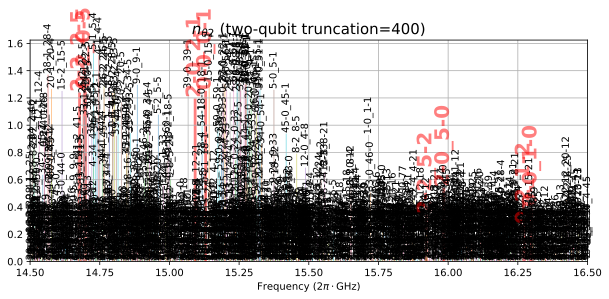

In [ ]:

fig, ax = plt.subplots(figsize=(10,4))
y_shift = 0.005
state_overlap = ['0-10']
x_shift = [-0.3]
x_min, x_max = 14.5, 16.5
for i,_ in enumerate(w_trans):
    if x_min < w_trans[i] < x_max:# and trans_mat[i] < 2:
        if trans[i] in ['2-0_5-0', '2-2_5-2',
                        '2-2_2-5', '0-2_0-5',
                        '2-0_2-1', '0-0_0-1',
                        '0-2_1-2', '0-0_1-0', ]:
            plt.bar(w_trans[i], trans_mat[i], width=0.01, color='red', alpha=0.5)
            plt.text(w_trans[i], trans_mat[i] +y_shift, trans[i],
                     ha="center", va="bottom", rotation=90, fontsize=20, fontweight='bold', color='red', alpha=0.5)
        else:
            plt.bar(w_trans[i], trans_mat[i], width=0.003, alpha=0.5)
            plt.text(w_trans[i], trans_mat[i] +y_shift, trans[i], ha="center", va="bottom", rotation=90, fontsize=10)

# plt.ylim(0,0.17)
plt.xlim(x_min,x_max)
plt.xlabel(r'Frequency (2$\pi\cdot$GHz)')
plt.grid()
# plt.xticks(np.arange(x_min, x_max, 2))  # Set custom x-axis ticks
# plt.ylabel('Max population during X gate')
ax.set_title(r'$n_{\theta 2}$ (two-qubit truncation=%d)'%truc_tot, fontsize=15)
# plt.title(r'$n_\phi:\psi_0=$'+f'{state_good}', fontsize=15)

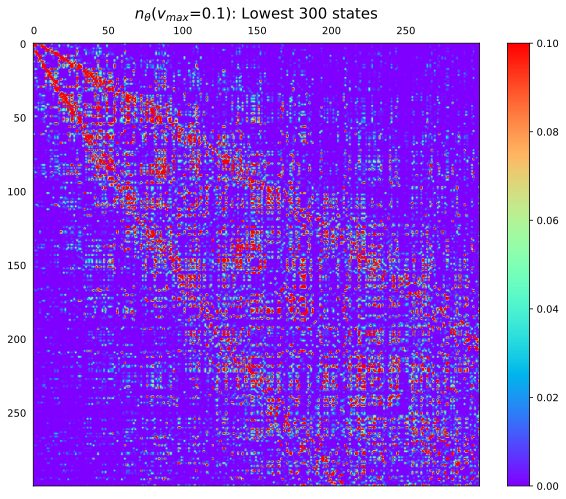

In [ ]:
vmax = 0.1
truc2 = 300
fig, ax = plt.subplots(figsize=(10,8))
font_size = 15
plt.imshow(np.abs(n_theta1_dress[:truc2,:truc2]), vmax=vmax, aspect="auto",cmap='rainbow')
plt.title(r'$n_{\theta}$($v_{max}$='+f'{vmax}): Lowest 300 states' , pad=8,fontsize=font_size)
# ax.set_xticks(np.arange(0, truc2, 1), np.arange(0, truc2, 1), fontsize=6)
# ax.set_yticks(np.arange(0, truc2, 1), np.arange(0, truc2, 1), fontsize=6)
ax.xaxis.tick_top()
# ax.set_xticks(np.arange(-.5, truc2, 1), minor=True)
# ax.set_yticks(np.arange(-.5, truc2, 1), minor=True)
ax.grid(which='minor', color='k', linestyle='-', linewidth=0.5)
ax.tick_params(which='both', left=False, top=False)
plt.colorbar()
# plt.savefig('image/n_theta.png',dpi=150, bbox_inches='tight')